<a href="https://colab.research.google.com/github/DinRazar/neural_networks/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [ ]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential

from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np

## 1.2. Разделяем данные на обучающую и тестовую выборку

In [ ]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

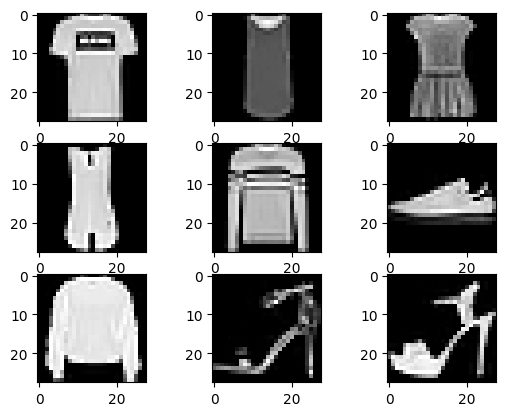

In [ ]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

In [ ]:
from tensorflow import keras

train_X = trainX / 255
test_X = testX / 255

train_Y = keras.utils.to_categorical(trainy, 10)
test_Y = keras.utils.to_categorical(testy, 10)

train_X = np.expand_dims(train_X, -1)
test_X = np.expand_dims(test_X, -1)

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10,  activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 1.5. Обучаем модель

In [ ]:
EPOCH = 5

model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])


history = model.fit(train_X, train_Y, batch_size=50, epochs=EPOCH, validation_split=0.2)

Epoch 1/5
960/960 ━━━━━━━━━━━━━━━━━━━━ 61s 60ms/step - accuracy: 0.7494 - loss: 0.7193 - val_accuracy: 0.8723 - val_loss: 0.3504
Epoch 2/5
960/960 ━━━━━━━━━━━━━━━━━━━━ 60s 62ms/step - accuracy: 0.8864 - loss: 0.3164 - val_accuracy: 0.8985 - val_loss: 0.2801
Epoch 3/5
960/960 ━━━━━━━━━━━━━━━━━━━━ 84s 64ms/step - accuracy: 0.9075 - loss: 0.2544 - val_accuracy: 0.9070 - val_loss: 0.2548
Epoch 4/5
960/960 ━━━━━━━━━━━━━━━━━━━━ 60s 62ms/step - accuracy: 0.9170 - loss: 0.2261 - val_accuracy: 0.9028 - val_loss: 0.2695
Epoch 5/5
960/960 ━━━━━━━━━━━━━━━━━━━━ 59s 61ms/step - accuracy: 0.9237 - loss: 0.2020 - val_accuracy: 0.9135 - val_loss: 0.2382


## 1.6. Анализируем обученную модель. Строим график (графики) обучения

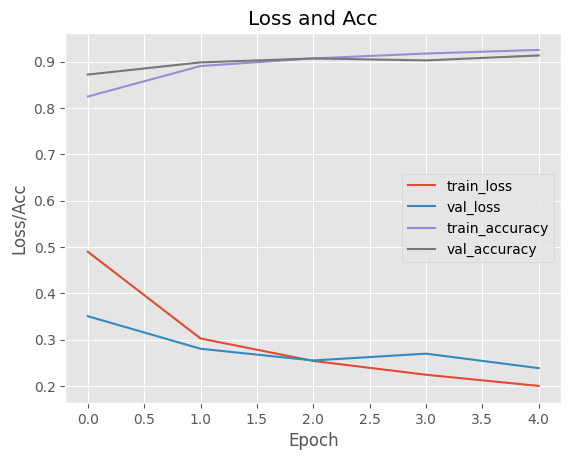

In [ ]:
N = np.arange(0, EPOCH)
plt.style.use("ggplot")
plt.figure()
plt.plot(N, history.history["loss"], label="train_loss")
plt.plot(N, history.history["val_loss"], label="val_loss")
plt.plot(N, history.history["accuracy"], label="train_accuracy")
plt.plot(N, history.history["val_accuracy"], label="val_accuracy")
plt.title("Loss and Acc")
plt.xlabel("Epoch")
plt.ylabel("Loss/Acc")
plt.legend()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



In [ ]:
from sklearn.preprocessing import LabelBinarizer
from keras.models import load_model
import pickle

model.save('model_fashion.keras')

labels = LabelBinarizer()
labels.fit_transform(train_Y)

with open('labels_fashion', 'wb') as f:
  f.write(pickle.dumps(labels))

print(labels.classes_)

[0 1 2 3 4 5 6 7 8 9]


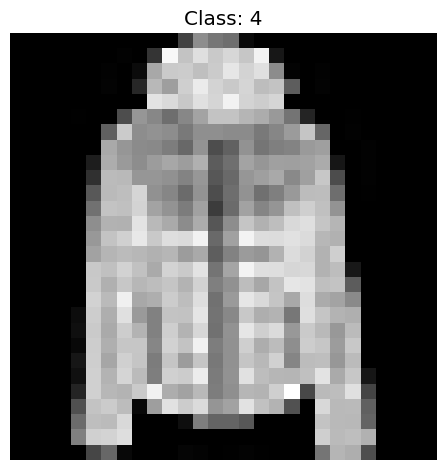

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Class	Prediction
0	0.00003
1	0.00056
2	0.00525
3	0.00005
4	0.99052
5	0.00027
6	0.00300
7	0.00000
8	0.00031
9	0.00000
Result of prediction: 4



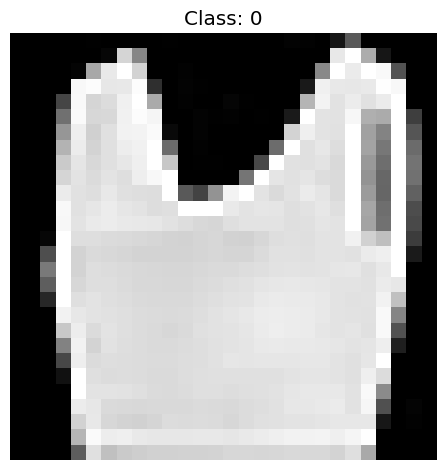

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
Class	Prediction
0	0.90693
1	0.00000
2	0.00032
3	0.00000
4	0.00000
5	0.00000
6	0.05487
7	0.00000
8	0.03788
9	0.00000
Result of prediction: 0



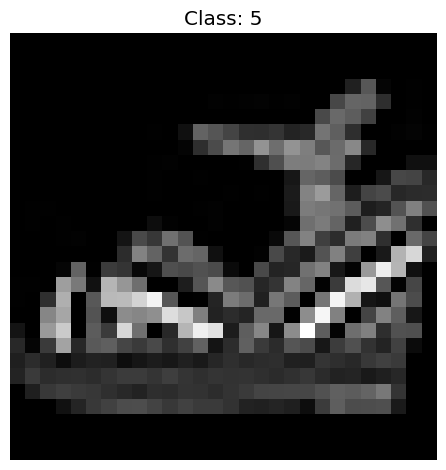

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
Class	Prediction
0	0.00000
1	0.00000
2	0.00000
3	0.00000
4	0.00000
5	0.99961
6	0.00001
7	0.00022
8	0.00016
9	0.00000
Result of prediction: 5



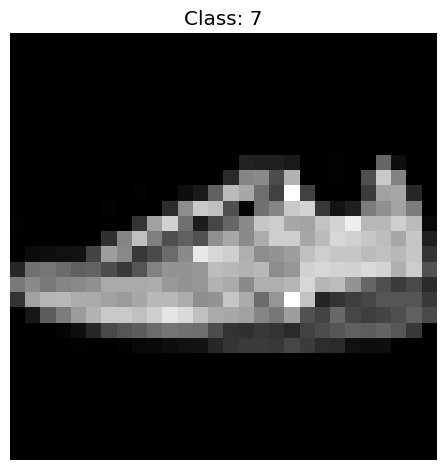

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Class	Prediction
0	0.00000
1	0.00000
2	0.00000
3	0.00000
4	0.00000
5	0.00001
6	0.00000
7	0.99998
8	0.00000
9	0.00000
Result of prediction: 7



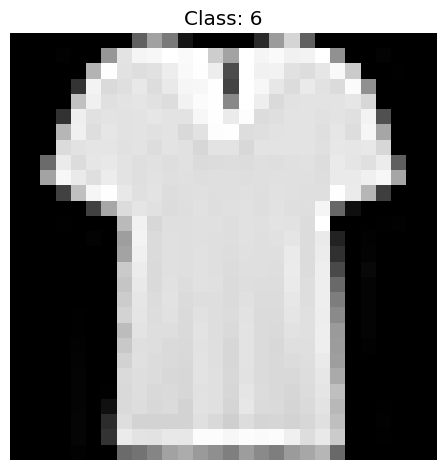

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
Class	Prediction
0	0.74562
1	0.00000
2	0.00026
3	0.00007
4	0.00000
5	0.00000
6	0.25400
7	0.00000
8	0.00004
9	0.00000
Result of prediction: 0



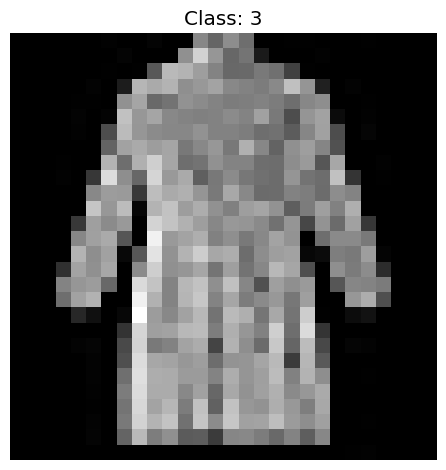

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Class	Prediction
0	0.23716
1	0.00174
2	0.10051
3	0.28094
4	0.07884
5	0.00026
6	0.29434
7	0.00062
8	0.00552
9	0.00007
Result of prediction: 6



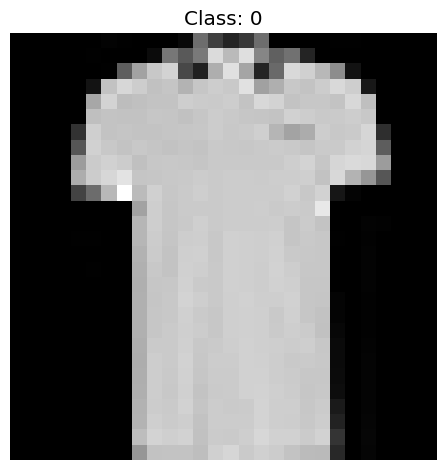

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Class	Prediction
0	0.99351
1	0.00001
2	0.00073
3	0.00046
4	0.00007
5	0.00000
6	0.00473
7	0.00000
8	0.00049
9	0.00000
Result of prediction: 0



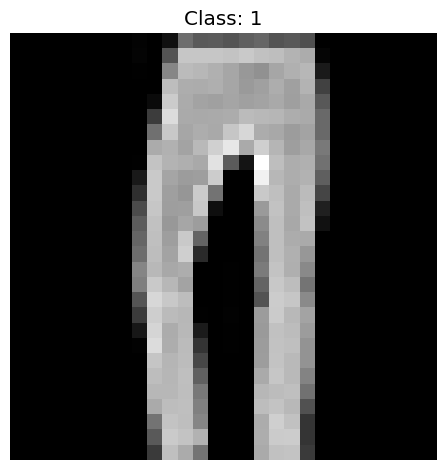

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Class	Prediction
0	0.00000
1	1.00000
2	0.00000
3	0.00000
4	0.00000
5	0.00000
6	0.00000
7	0.00000
8	0.00000
9	0.00000
Result of prediction: 1



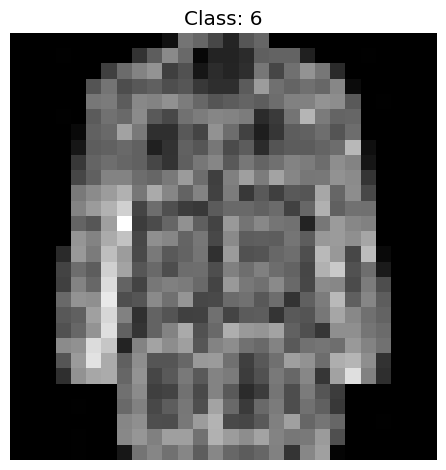

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Class	Prediction
0	0.01973
1	0.00135
2	0.02107
3	0.04735
4	0.18818
5	0.00144
6	0.71578
7	0.00013
8	0.00427
9	0.00071
Result of prediction: 6



In [ ]:
def predict_fashion(image, model_path = 'model_fashion.keras', labels_path = 'labels_fashion'):
  model = load_model(model_path)
  lb = pickle.loads(open(labels_path, 'rb').read())

  img = image.reshape(-1, 28, 28, 1)

  preds = model.predict(img)
  preds = preds[0]
  print('Class\tPrediction')
  for i in range(len(preds)):
    print(f'{lb.classes_[i]}\t{preds[i]:.5f}')
  print(f'Result of prediction: {preds.argmax()}\n')

num = np.random.randint(0, 9999, size=10)

for i in range(1, 10):
    plt.plot()
    plt.title(f'Class: {test_Y[num[i]].argmax()}')
    plt.imshow(testX[num[i]], cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    predict_fashion(test_X[num[i]])

# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [1]:
# Подготовка данных (самолеты-0, корабли-8, грузовики-9)
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Загрузка и фильтрация данных (берем только 3 класса)
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()
classes = [0, 8, 9]

# Фильтруем данные
train_mask = np.isin(y_train_full, classes).flatten()
X_train = X_train_full[train_mask]
y_train = y_train_full[train_mask]
test_mask = np.isin(y_test_full, classes).flatten()
X_test = X_test_full[test_mask]
y_test = y_test_full[test_mask]

# Переназначаем классы с 0,8,9 на 0,1,2
y_train = np.array([classes.index(y[0]) for y in y_train])
y_test = np.array([classes.index(y[0]) for y in y_test])

# Нормализация и one-hot encoding
X_train = X_train / 255.0
X_test = X_test / 255.0
y_train = to_categorical(y_train, 3)
y_test = to_categorical(y_test, 3)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train: (15000, 32, 32, 3), Test: (3000, 32, 32, 3)


In [2]:
# Создание простой модели
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model1 = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,115 (477.01 KB)

 Trainable params: 122,115 (477.01 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Компиляция и обучение
model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history1 = model1.fit(X_train, y_train,
                      epochs=10,
                      batch_size=64,
                      validation_split=0.2,
                      verbose=1)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 31s 132ms/step - accuracy: 0.6387 - loss: 0.7932 - val_accuracy: 0.7657 - val_loss: 0.5759
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.7910 - loss: 0.5256 - val_accuracy: 0.8327 - val_loss: 0.4377
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - accuracy: 0.8377 - loss: 0.4210 - val_accuracy: 0.8547 - val_loss: 0.3860
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 42s 129ms/step - accuracy: 0.8684 - loss: 0.3492 - val_accuracy: 0.8747 - val_loss: 0.3282
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - accuracy: 0.8837 - loss: 0.3083 - val_accuracy: 0.8760 - val_loss: 0.3338
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 42s 130ms/step - accuracy: 0.9004 - loss: 0.2662 - val_accuracy: 0.8677 - val_loss: 0.3788
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - accuracy: 0.9099 - loss: 0.2406 - val_accuracy: 0.8723 - val_loss: 0.3371
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 124ms/step - accuracy: 0.9161 - loss: 0

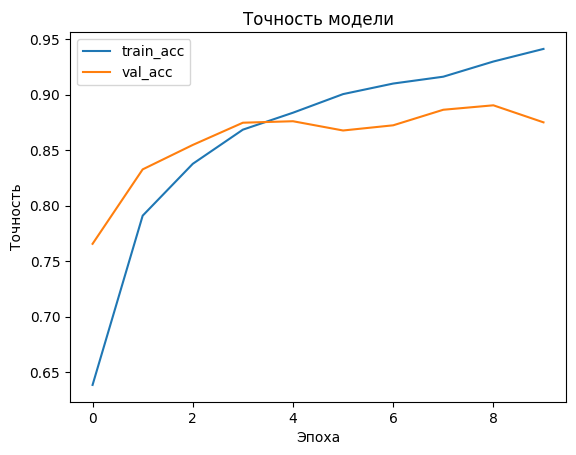

In [4]:
# Графики обучения
plt.plot(history1.history['accuracy'], label='train_acc')
plt.plot(history1.history['val_accuracy'], label='val_acc')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.show()

## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [5]:
# Вдохновлялся архитектурой VGG (маленькие фильтры 3x3, увеличение глубины)
model2 = Sequential([
    # Блок 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    # Блок 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    # Блок 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

print("Архитектура вдохновлена VGGNet: последовательные свертки 3x3, удвоение фильтров")
model2.summary()

Архитектура вдохновлена VGGNet: последовательные свертки 3x3, удвоение фильтров


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 844,835 (3.22 MB)

 Trainable params: 844,835 (3.22 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Компиляция и обучение
model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(X_train, y_train,
                      epochs=10,
                      batch_size=64,
                      validation_split=0.2,
                      verbose=1)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 89s 444ms/step - accuracy: 0.5727 - loss: 0.8731 - val_accuracy: 0.7087 - val_loss: 0.6777
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 83s 442ms/step - accuracy: 0.7515 - loss: 0.5904 - val_accuracy: 0.7890 - val_loss: 0.4940
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 143s 446ms/step - accuracy: 0.8374 - loss: 0.4117 - val_accuracy: 0.8630 - val_loss: 0.3524
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 83s 441ms/step - accuracy: 0.8712 - loss: 0.3315 - val_accuracy: 0.8697 - val_loss: 0.3472
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 83s 443ms/step - accuracy: 0.8936 - loss: 0.2748 - val_accuracy: 0.8947 - val_loss: 0.2862
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 142s 445ms/step - accuracy: 0.9210 - loss: 0.2128 - val_accuracy: 0.8980 - val_loss: 0.2710
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 84s 444ms/step - accuracy: 0.9370 - loss: 0.1662 - val_accuracy: 0.8897 - val_loss: 0.3014
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 141s 440ms/step - accuracy: 0.9496 - loss

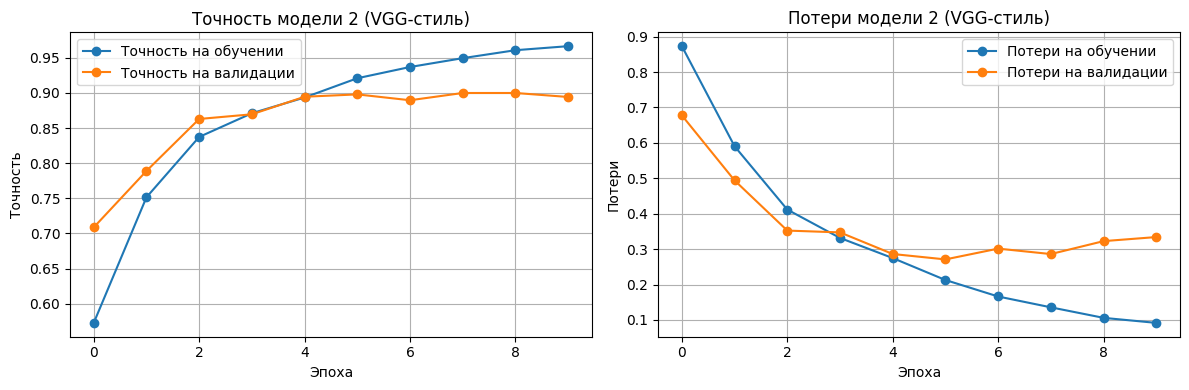

In [8]:
# График точности для model2
plt.figure(figsize=(12, 4))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Точность на обучении', marker='o')
plt.plot(history2.history['val_accuracy'], label='Точность на валидации', marker='o')
plt.title('Точность модели 2 (VGG-стиль)')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.grid(True)

# График потерь
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Потери на обучении', marker='o')
plt.plot(history2.history['val_loss'], label='Потери на валидации', marker='o')
plt.title('Потери модели 2 (VGG-стиль)')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 2.3. Сохраните полученные модели

In [9]:
# Сохраняем обе модели
model1.save('model_cnn_simple.h5')
model2.save('model_cnn_vgg.h5')
print("Модели сохранены")

Модели сохранены


In [10]:
model1.save('model_cnn_simple.keras')
model2.save('model_cnn_vgg.keras')
print("Модели сохранены в формате .keras")

Модели сохранены в формате .keras


## 2.4. Загрузите обученную модель из прошлой практической работы


In [11]:
from tensorflow.keras.models import load_model

try:
    model_prev = load_model('/content/best_model.keras')
    print("Модель загружена")
except:
    print("Файл best_model.keras не найден")
    # Создаем простую модель для демонстрации
    model_prev = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model_prev.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    print("Создана демо-модель")

Модель загружена



## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [12]:
# Функция для предсказания
def predict_and_show(model, X, y_true, idx):
    pred = model.predict(X[idx:idx+1])
    pred_class = np.argmax(pred)
    true_class = np.argmax(y_true[idx])
    confidence = np.max(pred)
    return pred_class, true_class, confidence

# Выбираем 15 случайных изображений
np.random.seed(42)
indices = np.random.choice(len(X_test), 15, replace=False)

print("Сравнение моделей (предсказанный класс / уверенность% | истинный класс)")
print("-" * 70)

for i, idx in enumerate(indices[:5]):  # Покажем первые 5 для примера
    img = X_test[idx]
    true = np.argmax(y_test[idx])

    # Предсказания всех моделей
    pred1, _, conf1 = predict_and_show(model1, X_test, y_test, idx)
    pred2, _, conf2 = predict_and_show(model2, X_test, y_test, idx)
    try:
        pred3, _, conf3 = predict_and_show(model_prev, X_test, y_test, idx)
    except:
        pred3, conf3 = "ошибка", 0

    print(f"Пример {i+1}: Истинный класс: {true}")
    print(f"  Модель 1 (простая): {pred1} ({conf1:.2%})")
    print(f"  Модель 2 (VGG-стиль): {pred2} ({conf2:.2%})")
    print(f"  Модель 3 (из работы 2): {pred3} ({conf3 if isinstance(conf3, float) else 'ошибка'})")
    print()

Сравнение моделей (предсказанный класс / уверенность% | истинный класс)
----------------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Пример 1: Истинный класс: 2
  Модель 1 (простая): 0 (98.05%)
  Модель 2 (VGG-стиль): 2 (98.64%)
  Модель 3 (из работы 2): ошибка (ошибка)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Пример 2: Истинный класс: 1
  Модель 1 (простая): 1 (99.81%)
  Модель 2 (VGG-стиль): 1 (100.00%)
  Модель 3 (из работы 2): ошибка (ошибка)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Пример 3: Истинный класс: 2
  Модель 1 (простая): 2 (99.92%)
  Модель 2 (VGG-стиль): 2 (100.00%)
  Модель 3 (из работы 2): ошибка (ошибка)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Пример 4: Истинный класс: 2
  Модель 1 (простая): 2 (100.00%)
  Модель 2 (VGG-стиль): 2 (100.00%)
  Модель 3 (из работы 2): ошибка (

In [15]:
# Общая точность на тестовых данных
print("Точность на тестовых данных:")
print(f"Модель 1 (простая): {model1.evaluate(X_test, y_test, verbose=0)[1]:.4f}")
print(f"Модель 2 (VGG-стиль): {model2.evaluate(X_test, y_test, verbose=0)[1]:.4f}")
try:
    print(f"Модель 3 (из работы 2): {model_prev.evaluate(X_test, y_test, verbose=0)[1]:.4f}")
except:
    print("Модель 3 не удалось оценить")

Точность на тестовых данных:
Модель 1 (простая): 0.8723
Модель 2 (VGG-стиль): 0.8850
Модель 3 не удалось оценить


# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [16]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [17]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [18]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

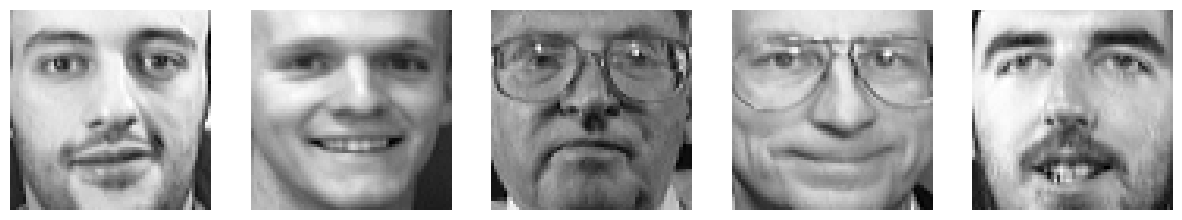

In [19]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [20]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [21]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

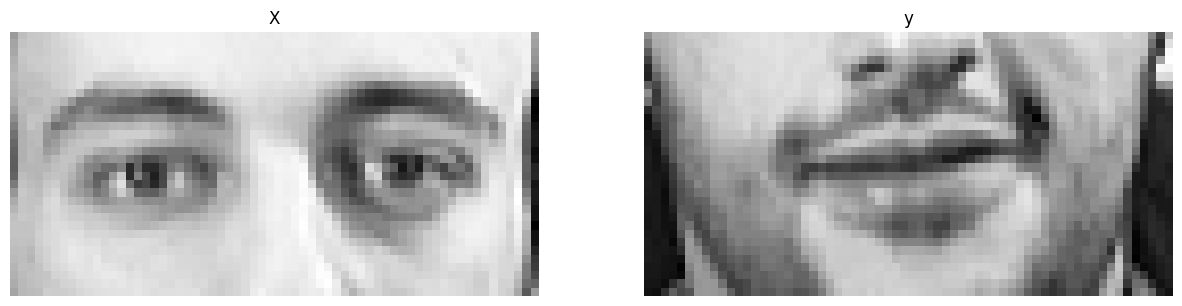

In [22]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [47]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [49]:
model_rec = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32, 64, 1)),
    MaxPooling2D((2,2), strides=2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), strides=2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2), strides=2),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(1024, activation='relu'),

    Dense(2048, activation='sigmoid'),
])

model_rec.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 8, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 16, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 4, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 2048)           │     2,099,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,188,992 (27.42 MB)

 Trainable params: 7,188,992 (27.42 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [50]:
model_faces.compile(optimizer='adam',
                    loss='mse',
                    metrics=['mae'])

## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [52]:
X_train_cnn = X_train.reshape(-1, 32, 64, 1)
X_test_cnn = X_test.reshape(-1, 32, 64, 1)

# y_train_flat уже имеет форму (320, 2048) - это правильно
print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"y_train_flat shape: {y_train_flat.shape}")

history_faces = model_faces.fit(
    X_train_cnn, y_train_flat,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

X_train_cnn shape: (320, 32, 64, 1)
y_train_flat shape: (320, 2048)
Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - loss: 0.0144 - mae: 0.0927 - val_loss: 0.0156 - val_mae: 0.1009
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - loss: 0.0125 - mae: 0.0872 - val_loss: 0.0134 - val_mae: 0.0889
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - loss: 0.0108 - mae: 0.0799 - val_loss: 0.0121 - val_mae: 0.0848
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - loss: 0.0098 - mae: 0.0747 - val_loss: 0.0116 - val_mae: 0.0806
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - loss: 0.0092 - mae: 0.0720 - val_loss: 0.0115 - val_mae: 0.0811
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - loss: 0.0089 - mae: 0.0711 - val_loss: 0.0113 - val_mae: 0.0807
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - loss: 0.0086 - mae: 0.0698 - val_loss: 0.0111 - val_mae: 0.0793
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - loss: 0.0084 - mae: 0.0684 - val_loss: 0.0110 - val_mae: 0.0785
Epoc

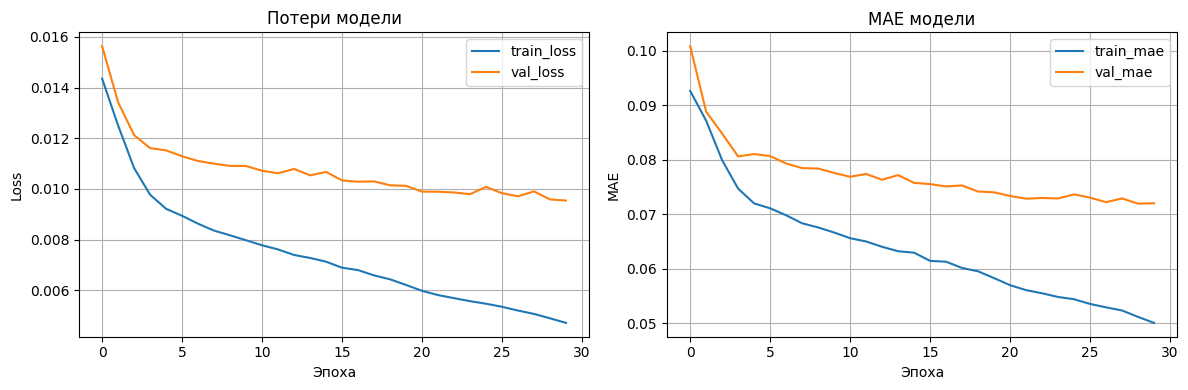

In [53]:
# Графики обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_faces.history['loss'], label='train_loss')
plt.plot(history_faces.history['val_loss'], label='val_loss')
plt.title('Потери модели')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_faces.history['mae'], label='train_mae')
plt.plot(history_faces.history['val_mae'], label='val_mae')
plt.title('MAE модели')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 3.5. Сделайте предсказания на тестовых данных

In [54]:
pred_flat = model_faces.predict(X_test_cnn)
print(f"Predictions shape: {pred_flat.shape}")

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Predictions shape: (80, 2048)


## 3.6. Посчитайте метрику качества на тестовых данных

In [55]:
from sklearn.metrics import mean_absolute_error
mae_score = mean_absolute_error(y_test_flat, pred_flat)
print(f"MAE: {mae_score:.4f}")

MAE: 0.0696


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [56]:
pred_images = pred_flat.reshape(-1, 32, 64)
print(f"Pred images shape: {pred_images.shape}")

Pred images shape: (80, 32, 64)


Отрисуйте все предсказания.

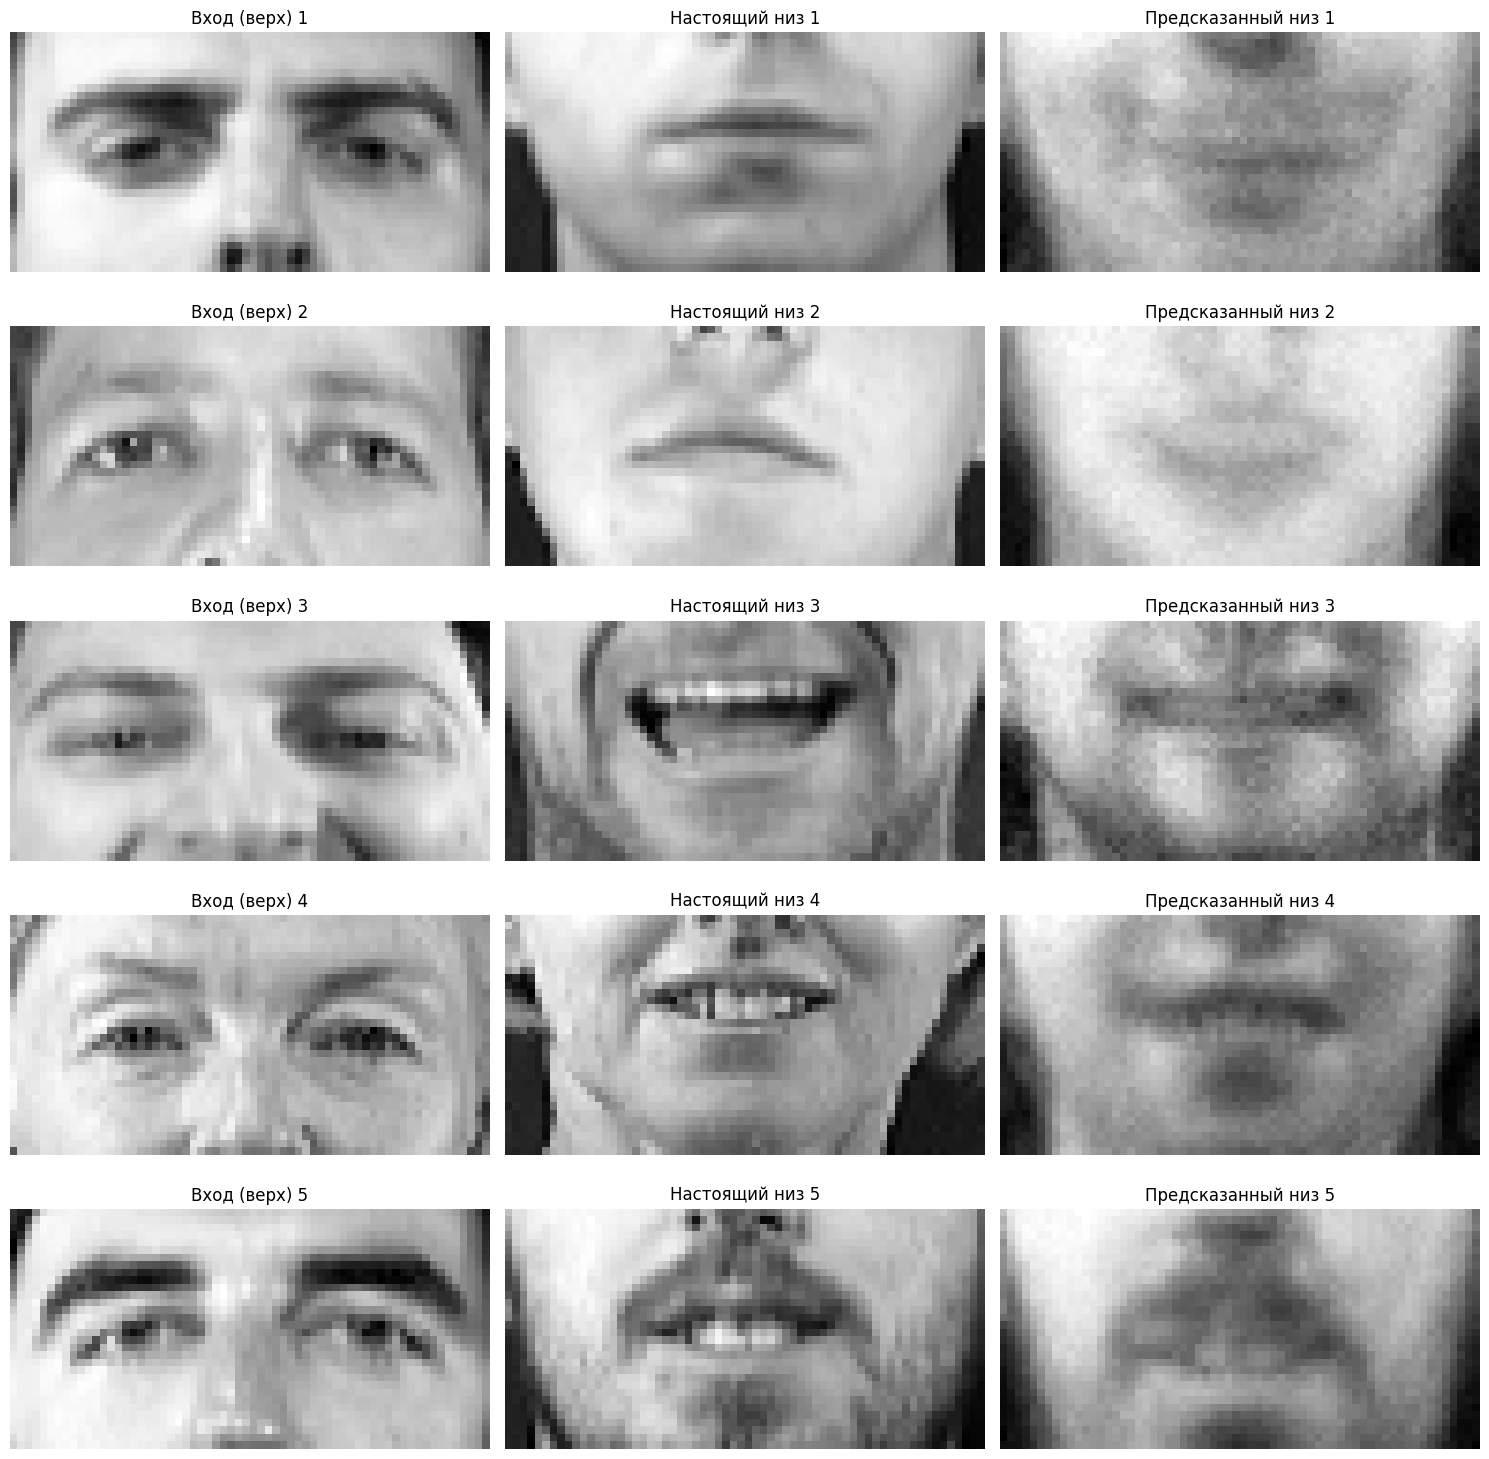

In [57]:
n_samples = 5
plt.figure(figsize=(15, 3*n_samples))

for i in range(n_samples):
    # Верхняя половина (вход)
    plt.subplot(n_samples, 3, i*3 + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'Вход (верх) {i+1}')
    plt.axis('off')

    # Настоящая нижняя половина
    plt.subplot(n_samples, 3, i*3 + 2)
    plt.imshow(y_test[i], cmap='gray')
    plt.title(f'Настоящий низ {i+1}')
    plt.axis('off')

    # Предсказанная нижняя половина
    plt.subplot(n_samples, 3, i*3 + 3)
    plt.imshow(pred_images[i], cmap='gray')
    plt.title(f'Предсказанный низ {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

Saving face.jpg to face (4).jpg

Загружен файл: face (4).jpg


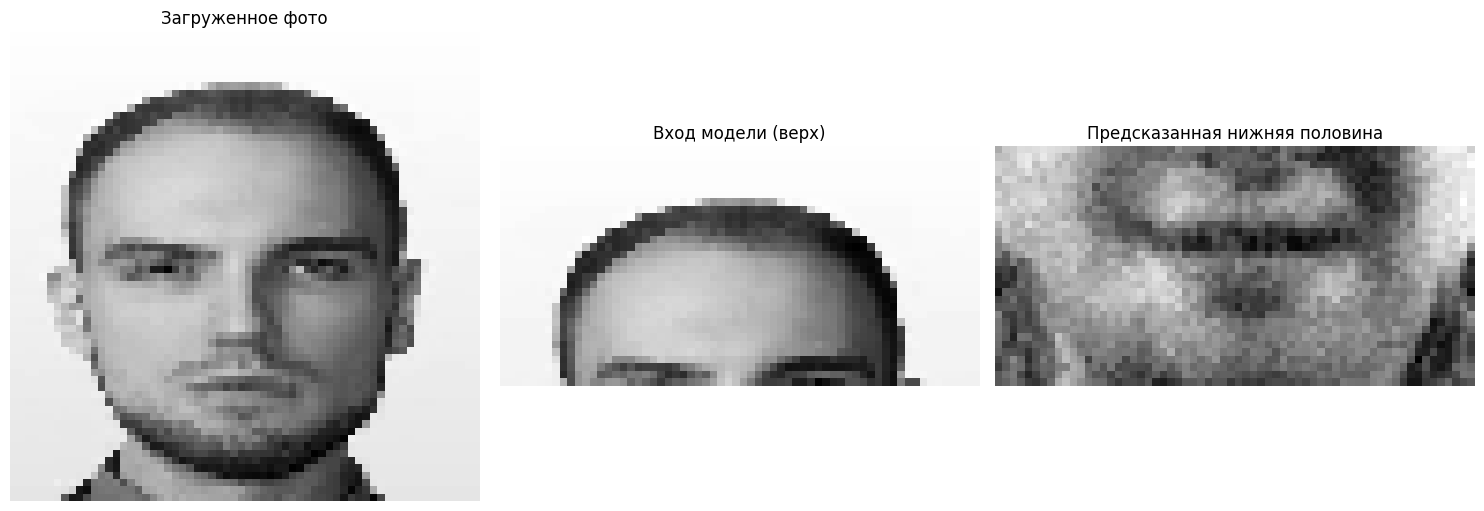

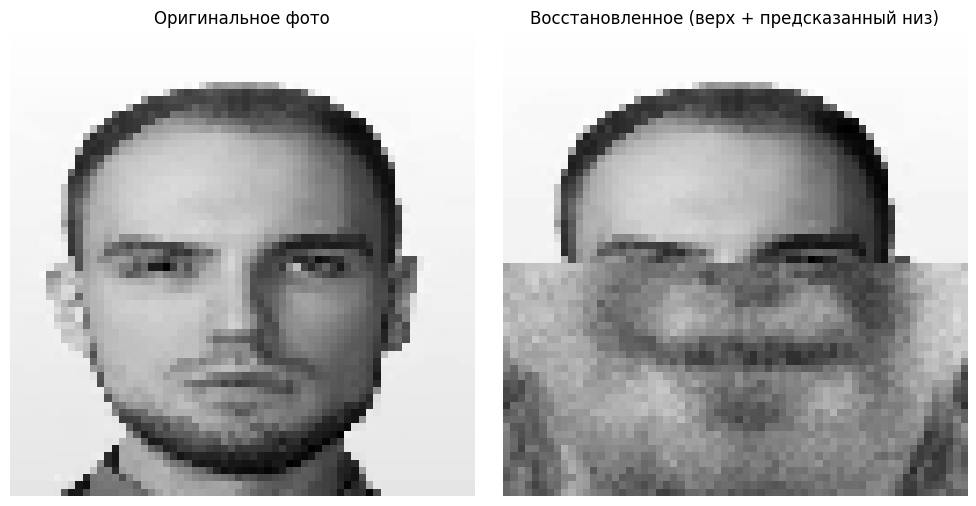

Угар, да?


In [68]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import io

# Загружаем файл
uploaded = files.upload()

# Получаем имя загруженного файла
for filename in uploaded.keys():
    print(f"\nЗагружен файл: {filename}")

    # Загружаем изображение из загруженных данных
    img = image.load_img(io.BytesIO(uploaded[filename]),
                         color_mode='grayscale',
                         target_size=(64, 64))

    # Преобразуем в массив и нормализуем
    img_array = image.img_to_array(img) / 255.0

    # Берем верхнюю половину
    upper_half = img_array[:32, :, :]

    # Подготавливаем для модели
    upper_half_input = upper_half.reshape(1, 32, 64, 1)

    # Предсказание нижней половины
    pred_lower_flat = model_faces.predict(upper_half_input, verbose=0)
    pred_lower = pred_lower_flat.reshape(32, 64)

    # Визуализация результатов
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Оригинал (все лицо)
    axes[0].imshow(img_array[:, :, 0], cmap='gray')
    axes[0].set_title('Загруженное фото')
    axes[0].axis('off')

    # Верхняя половина (вход модели)
    axes[1].imshow(upper_half[:, :, 0], cmap='gray')
    axes[1].set_title('Вход модели (верх)')
    axes[1].axis('off')

    # Предсказанная нижняя половина
    axes[2].imshow(pred_lower, cmap='gray')
    axes[2].set_title('Предсказанная нижняя половина')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Показываем восстановленное лицо
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    # Оригинал
    ax[0].imshow(img_array[:, :, 0], cmap='gray')
    ax[0].set_title('Оригинальное фото')
    ax[0].axis('off')

    # Восстановленное (верх настоящий + низ предсказанный)
    reconstructed = np.vstack([upper_half[:, :, 0], pred_lower])
    ax[1].imshow(reconstructed, cmap='gray')
    ax[1].set_title('Восстановленное (верх + предсказанный низ)')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

    print("Угар, да?")